In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

df = pd.read_csv('amz_uk_price_prediction_dataset.csv')
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


## Part 1 - Product Categories

In [2]:
# Frequency table
cat_freq = df['category'].value_counts()
cat_pct = df['category'].value_counts(normalize=True).mul(100).round(2)
freq_table = pd.DataFrame({'Count': cat_freq, '%': cat_pct})
print('Top 5 categories:')
freq_table.head()

Top 5 categories:


,Count,%
category,,
Sports & Outdoors,836265,34.22
Beauty,19312,0.79
"Handmade Clothing, Shoes & Accessories",19229,0.79
Bath & Body,19092,0.78
Birthday Gifts,18978,0.78


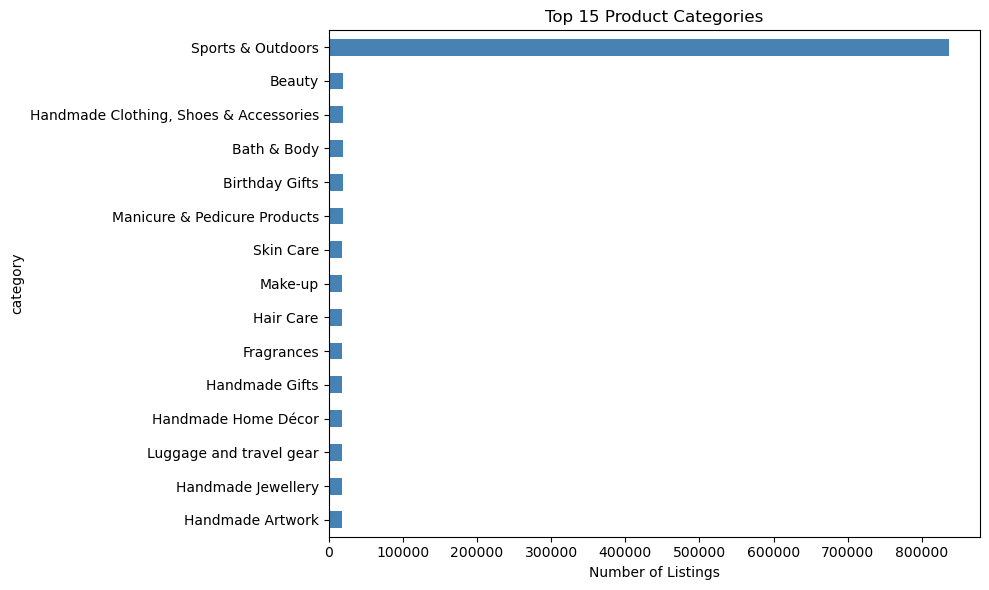

In [3]:
# Bar chart - top 15 categories
top15 = cat_freq.head(15)
top15[::-1].plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Top 15 Product Categories')
plt.xlabel('Number of Listings')
plt.tight_layout()
plt.show()

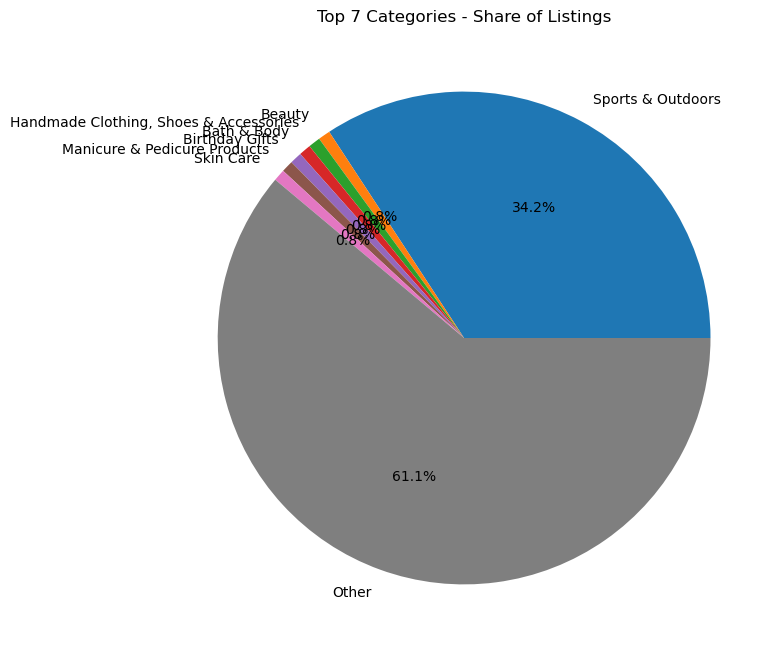

In [4]:
# Pie chart - top 7 categories
top7 = cat_freq.head(7)
other = pd.Series({'Other': cat_freq.iloc[7:].sum()})
pie_data = pd.concat([top7, other])
pie_data.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Top 7 Categories - Share of Listings')
plt.ylabel('')
plt.show()

## Part 2 - Product Pricing

In [5]:
# Central tendency
price = pd.to_numeric(df['price'], errors='coerce').dropna()
price = price[price > 0]

print(f'Mean:   £{price.mean():.2f}')
print(f'Median: £{price.median():.2f}')
print(f'Mode:   £{price.mode()[0]:.2f}')

Mean:   £89.24
Median: £19.09
Mode:   £9.99


In [6]:
# Dispersion
print(f'Variance:  £{price.var():.2f}')
print(f'Std Dev:   £{price.std():.2f}')
print(f'Range:     £{price.max() - price.min():.2f}')
print(f'IQR:       £{price.quantile(0.75) - price.quantile(0.25):.2f}')

Variance:  £119446.40
Std Dev:   £345.61
Range:     £99999.99
IQR:       £36.00


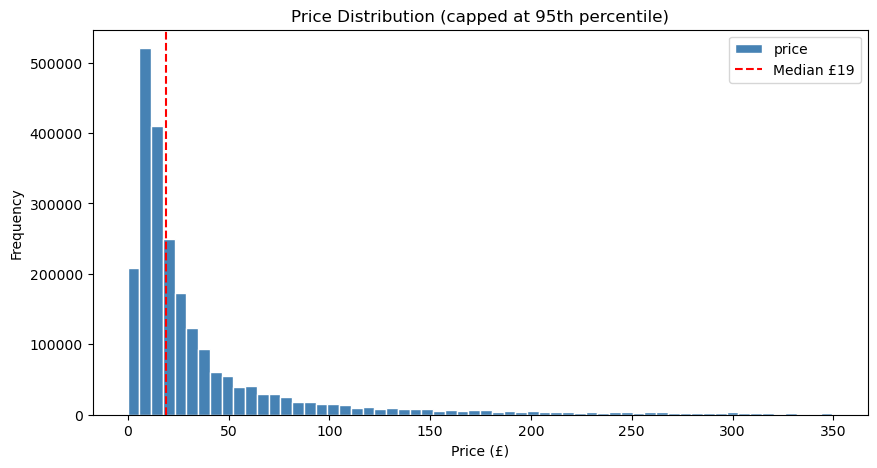

In [ ]:
# Histogram - capped at 95th percentile for readability
cap = price.quantile(0.95)
price[price <= cap].plot(kind='hist', bins=60, figsize=(10, 5), color='steelblue', edgecolor='white')
plt.axvline(price.median(), color='red', linestyle='--', label=f'Median £{price.median():.0f}')
plt.title('Price Distribution (capped at 95th percentile)')
plt.xlabel('Price (£)')
plt.legend()
plt.show()

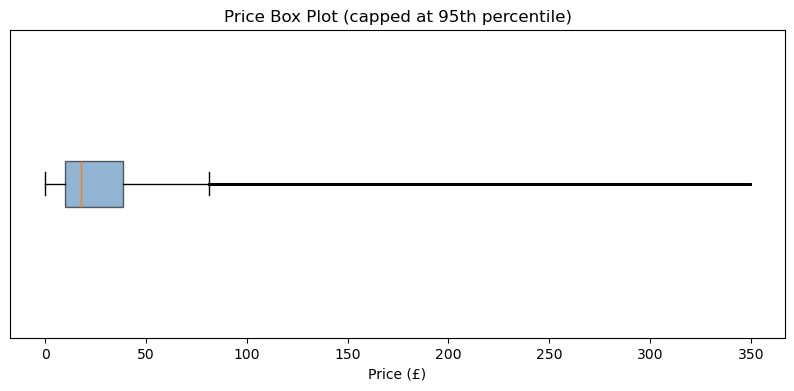

In [8]:
# Box plot
plt.figure(figsize=(10, 4))
plt.boxplot(price[price <= cap], vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            flierprops=dict(marker='.', markersize=2, alpha=0.3))
plt.title('Price Box Plot (capped at 95th percentile)')
plt.xlabel('Price (£)')
plt.yticks([])
plt.show()

## Part 3 - Product Ratings

In [9]:
# Central tendency
rating = pd.to_numeric(df['stars'], errors='coerce').dropna()
rating = rating[(rating >= 1) & (rating <= 5)]

print(f'Mean:   {rating.mean():.3f}')
print(f'Median: {rating.median():.3f}')
print(f'Mode:   {rating.mode()[0]:.1f}')

Mean:   4.319
Median: 4.400
Mode:   4.5


In [10]:
# Dispersion
print(f'Variance:  {rating.var():.4f}')
print(f'Std Dev:   {rating.std():.4f}')
print(f'IQR:       {rating.quantile(0.75) - rating.quantile(0.25):.4f}')

Variance:  0.3083
Std Dev:   0.5553
IQR:       0.5000


In [11]:
# Skewness and kurtosis
print(f'Skewness: {stats.skew(rating):.4f}')
print(f'Kurtosis: {stats.kurtosis(rating):.4f}')

Skewness: -2.3796
Kurtosis: 9.7819


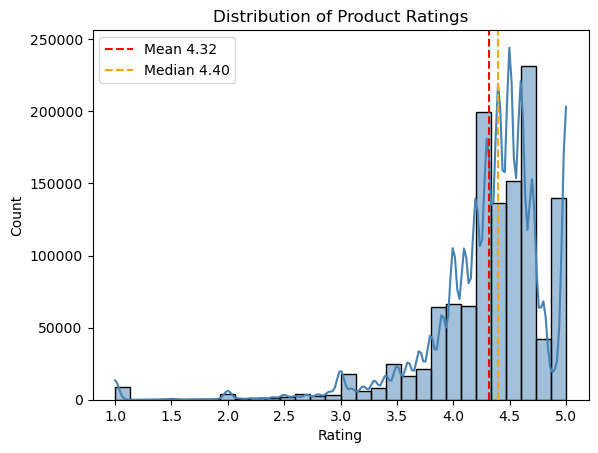

In [12]:
# Histogram
sns.histplot(rating, bins=30, kde=True, color='steelblue')
plt.axvline(rating.mean(), color='red', linestyle='--', label=f'Mean {rating.mean():.2f}')
plt.axvline(rating.median(), color='orange', linestyle='--', label=f'Median {rating.median():.2f}')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.legend()
plt.show()